In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import plotly.express as px

In [7]:
iris = load_iris()

In [8]:
X = iris.data
y = iris.target

In [9]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
df_plot = pd.DataFrame({"'sepal length (cm)'": X[:,0], " 'sepal width (cm)'":X[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "'sepal length (cm)'", y= " 'sepal width (cm)'", color="Type")

In [11]:
df_plot = pd.DataFrame({'petal length (cm)': X[:,2], 'petal width (cm)':X[:,3], "Type": iris.target_names[y]})
px.scatter(df_plot, x = 'petal length (cm)', y= 'petal width (cm)', color="Type")

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X) 

In [13]:
df_plot = pd.DataFrame({"'sepal length (cm)'": X[:,0], " 'sepal width (cm)'":X[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "'sepal length (cm)'", y= " 'sepal width (cm)'", color="Type")

In [14]:
df_plot = pd.DataFrame({'petal length (cm)': X[:,2], 'petal width (cm)':X[:,3], "Type": iris.target_names[y]})
px.scatter(df_plot, x = 'petal length (cm)', y= 'petal width (cm)', color="Type")

In [15]:
y = iris.target

In [16]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [17]:
pca = PCA(n_components=2, random_state=32)
X_pca = pca.fit_transform(X)

In [18]:
df_plot = pd.DataFrame({"PC1": X_pca[:,0], "PC2":X_pca[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")

In [19]:
df_plot = pd.DataFrame({"PC1": X_pca[:,0], "PC2":X_pca[:,1], "Type": y})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")

# K-MEANS

In [20]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=32, n_init="auto")
clusters = kmeans.fit_predict(X_pca)

In [21]:
df_plot = pd.DataFrame({"PC1": X_pca[:,0], "PC2":X_pca[:,1], "Type": clusters})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")

In [22]:
kmeans.cluster_centers_

array([[ 1.63395833,  0.48398172],
       [-2.23223542,  0.34252628],
       [ 0.42417016, -0.94353874]])

In [23]:
kmeans.inertia_

116.01774316704248

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

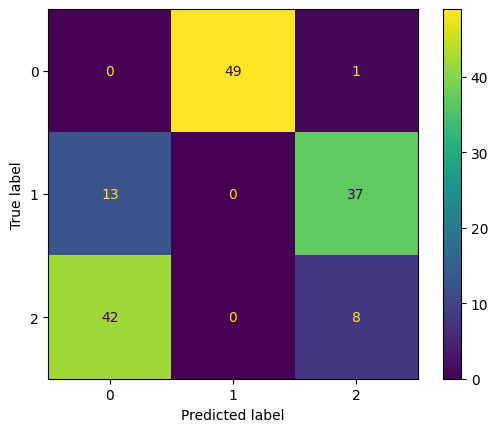

In [25]:
ConfusionMatrixDisplay.from_predictions(y, clusters)

In [26]:
cm = confusion_matrix(y, clusters)

In [27]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import silhouette_score

In [28]:
sse = []
list_k = []
silhouette =[]
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=32, n_init="auto")
    clusters = kmeans.fit_predict(X_pca)
    silhouette.append(silhouette_score(X_pca, clusters))
    
    sse.append(kmeans.inertia_)
    list_k.append(k)

In [29]:
px.line(pd.DataFrame({"SSD": sse, "k":list_k}), x="k", y = "SSD")

In [30]:
px.line(pd.DataFrame({"silhouette": silhouette, "k":list_k}), x="k", y = "silhouette")

In [31]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

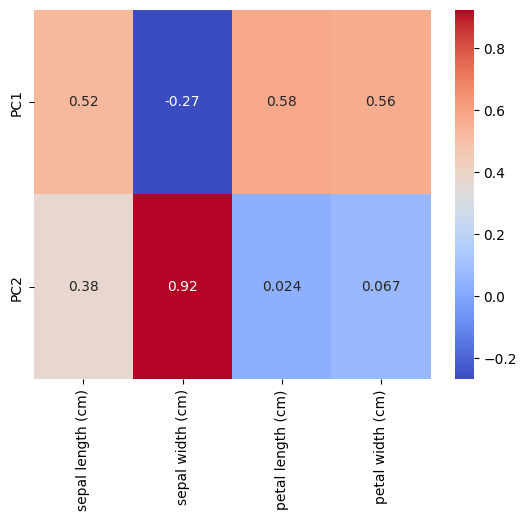

In [32]:
component_df = pd.DataFrame(pca.components_, columns=iris.feature_names, index=["PC1", "PC2"])
import seaborn as sns
sns.heatmap(component_df, annot=True, cmap="coolwarm")

In [33]:
print(f"Explained variability {pca.explained_variance_ratio_}")
      

Explained variability [0.72962445 0.22850762]


In [34]:
np.sum(pca.explained_variance_ratio_)


np.float64(0.9581320720000164)

In [39]:
from sklearn.decomposition import FastICA
ica = FastICA(n_components=2, random_state=32)
X_ica = ica.fit_transform(X)

In [41]:
df_plot = pd.DataFrame({"PC1": X_ica[:,0], "PC2":X_ica[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "PC1", y= "PC2", color="Type")

In [47]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=40,learning_rate="auto", init = "pca")
X_tsne = tsne.fit_transform(X)

In [48]:
plt.figure(figsize=(10,6))
df_plot = pd.DataFrame({"TSNE1": X_tsne[:,0], "TSNE2": X_tsne[:,1], "Type": iris.target_names[y]})
px.scatter(df_plot, x = "TSNE1", y= "TSNE2", color="Type")

<Figure size 1000x600 with 0 Axes>

In [ ]:
SALUT